Attrition = Employees leaving the company permanently.
✅ Employee leaves job = Attrition = 1 (Yes)
❌ Employee stays     = No attrition = 0 (No)

In [50]:
#Import operational packages
import pandas as pd
import numpy as np

#Import visulaisation packages
import matplotlib.pyplot as plt
import seaborn as sns

#Import machine learning packages
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.ensemble import RandomForestClassifier

In [6]:
# Reading dataset
data=pd.read_csv("HR_Employee_Attrition.csv")

In [8]:
# checking dataset
data.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [12]:
# Shape of dataset
data.shape

(1470, 35)

In [9]:
# To identify which columns are useful for dataset. 
data.columns

Index(['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department',
       'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount',
       'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate',
       'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction',
       'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked',
       'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating',
       'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel',
       'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance',
       'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager'],
      dtype='object')

In [13]:
# We created a copy of data in data2 to do operations
data2=data.copy()

In [26]:
# information of dataset
data2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 31 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EnvironmentSatisfaction   1470 non-null   int64 
 9   Gender                    1470 non-null   object
 10  HourlyRate                1470 non-null   int64 
 11  JobInvolvement            1470 non-null   int64 
 12  JobLevel                  1470 non-null   int64 
 13  JobRole                   1470 non-null   object
 14  JobSatisfaction         

In [27]:
# # finding any missing value
data2.isnull().sum()

Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSinceLastPromotion     0
YearsWithCurrManager        0
dtype: int64

In [34]:
# EmployeeCount", "EmployeeNumber","StandardHours","Over18 these columns are useless so we need to drop them.
drop_cols = ["EmployeeCount", "EmployeeNumber","StandardHours","Over18"]
data2 = data2.drop(columns=drop_cols)
print(data2.shape)

(1470, 31)


In [36]:
# Columns droped
data2.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,...,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,2,Female,...,3,1,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,3,Male,...,4,4,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,4,Male,...,3,2,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,4,Female,...,3,3,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,Male,...,3,4,1,6,3,3,2,2,2,2


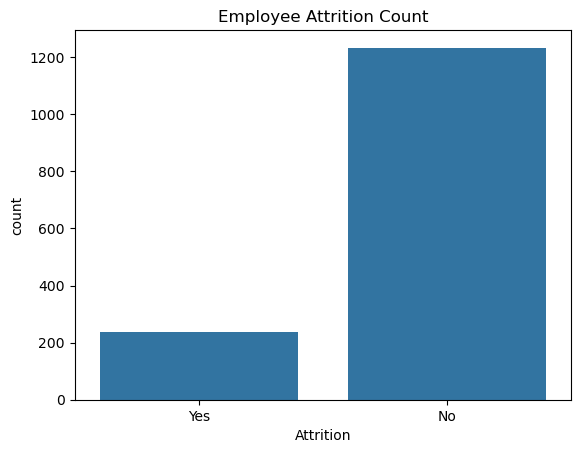

In [37]:
# Visulalisation of attrition,overtion,job satisfaction,monthly income,years at company,departmwent wise action
sns.countplot(x="Attrition", data=data2)
plt.title("Employee Attrition Count")
plt.show()

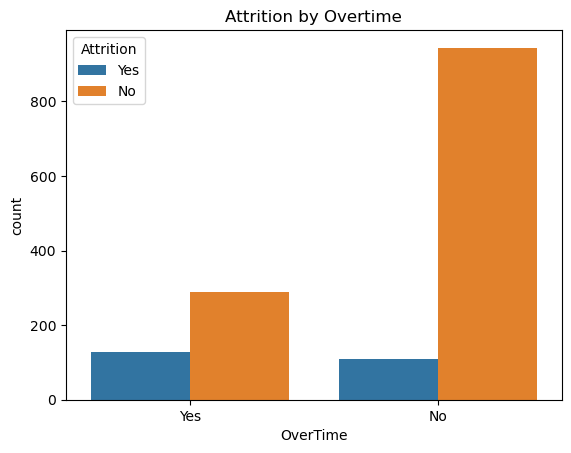

In [39]:
sns.countplot(x="OverTime", hue="Attrition", data=data2)
plt.title("Attrition by Overtime")
plt.show() 

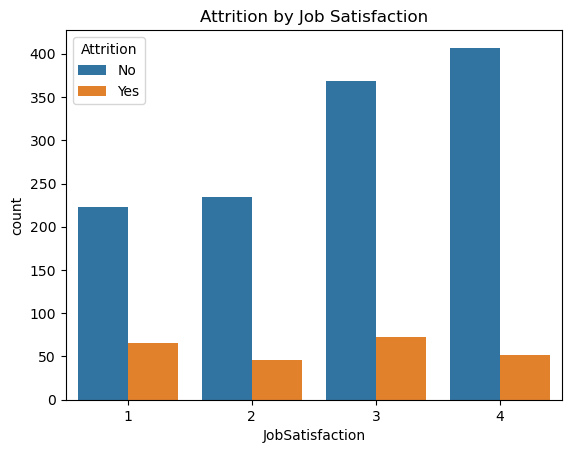

In [40]:
sns.countplot(x="JobSatisfaction", hue="Attrition", data=data2)
plt.title("Attrition by Job Satisfaction")
plt.show() 

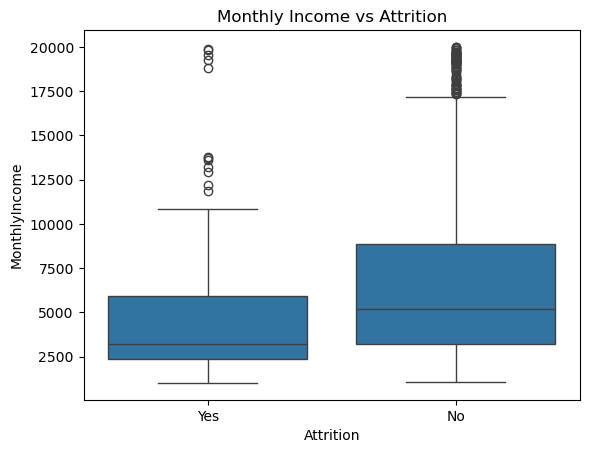

In [41]:
sns.boxplot(x="Attrition", y="MonthlyIncome", data=data2)
plt.title("Monthly Income vs Attrition")
plt.show()

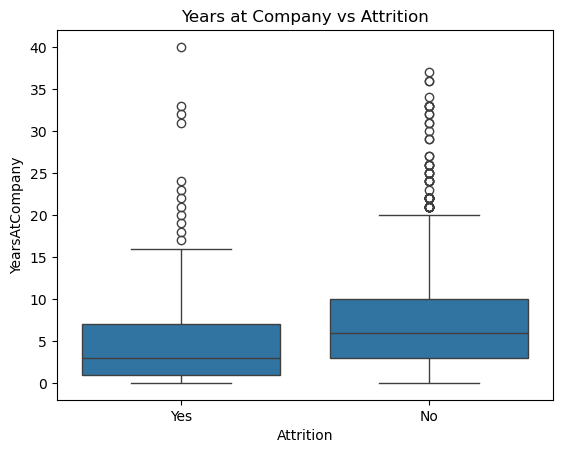

In [42]:
sns.boxplot(x="Attrition", y="YearsAtCompany", data=data2)
plt.title("Years at Company vs Attrition")
plt.show()

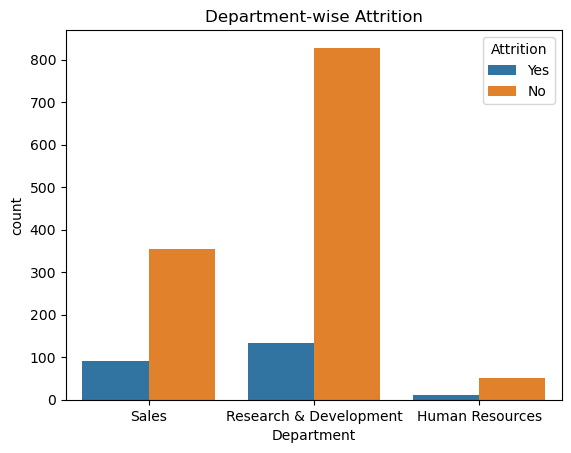

In [44]:
sns.countplot(x="Department", hue="Attrition", data=data2)
plt.title("Department-wise Attrition")
plt.show()

In [45]:
data2.select_dtypes(include="object").columns

Index(['Attrition', 'BusinessTravel', 'Department', 'EducationField', 'Gender',
       'JobRole', 'MaritalStatus', 'OverTime'],
      dtype='object')

In [46]:
df_model = data2.copy()

# One-hot encode categorical columns
df_model = pd.get_dummies(df_model, columns=df_model.select_dtypes(include="object").columns)

print("Shape after one-hot encoding:", df_model.shape)
df_model.head()

Shape after one-hot encoding: (1470, 53)


,Age,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,MonthlyIncome,...,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Divorced,MaritalStatus_Married,MaritalStatus_Single,OverTime_No,OverTime_Yes
0,41,1102,1,2,2,94,3,2,4,5993,...,False,False,False,True,False,False,False,True,False,True
1,49,279,8,1,3,61,2,2,2,5130,...,False,False,True,False,False,False,True,False,True,False
2,37,1373,2,2,4,92,2,1,3,2090,...,False,False,False,False,False,False,False,True,False,True
3,33,1392,3,4,4,56,3,1,3,2909,...,False,False,True,False,False,False,True,False,False,True
4,27,591,2,1,1,40,3,1,2,3468,...,False,False,False,False,False,False,True,False,True,False


In [47]:
# The columns are increased for yes and not
df_model.columns

Index(['Age', 'DailyRate', 'DistanceFromHome', 'Education',
       'EnvironmentSatisfaction', 'HourlyRate', 'JobInvolvement', 'JobLevel',
       'JobSatisfaction', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked',
       'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction',
       'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear',
       'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole',
       'YearsSinceLastPromotion', 'YearsWithCurrManager', 'Attrition_No',
       'Attrition_Yes', 'BusinessTravel_Non-Travel',
       'BusinessTravel_Travel_Frequently', 'BusinessTravel_Travel_Rarely',
       'Department_Human Resources', 'Department_Research & Development',
       'Department_Sales', 'EducationField_Human Resources',
       'EducationField_Life Sciences', 'EducationField_Marketing',
       'EducationField_Medical', 'EducationField_Other',
       'EducationField_Technical Degree', 'Gender_Female', 'Gender_Male',
       'JobRole_Healthcare Repr

In [48]:
#CORRELATION
corr = df_model.corr()
corr

,Age,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,MonthlyIncome,...,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Divorced,MaritalStatus_Married,MaritalStatus_Single,OverTime_No,OverTime_Yes
Age,1.000000,0.010661,-0.001686,0.208034,0.010146,0.024287,0.029820,0.509604,-0.004892,0.497855,...,0.049726,0.185891,-0.146518,-0.002001,-0.175785,0.033120,0.083919,-0.119185,-0.028062,0.028062
DailyRate,0.010661,1.000000,-0.004985,-0.016806,0.018355,0.023381,0.046135,0.002966,0.030571,0.007707,...,-0.005302,-0.000021,-0.002624,-0.000513,0.005375,0.037080,0.040035,-0.075835,-0.009135,0.009135
DistanceFromHome,-0.001686,-0.004985,1.000000,0.021042,-0.016075,0.031131,0.008783,0.005303,-0.003669,-0.017014,...,0.011848,-0.022351,-0.010986,0.030761,-0.015994,-0.005440,0.030232,-0.027445,-0.025514,0.025514
Education,0.208034,-0.016806,0.021042,1.000000,-0.027128,0.016775,0.042438,0.101589,-0.011296,0.094961,...,-0.005290,0.049694,0.000709,0.053398,-0.091465,-0.002439,-0.001865,0.004168,0.020322,-0.020322
EnvironmentSatisfaction,0.010146,0.018355,-0.016075,-0.027128,1.000000,-0.049857,-0.008278,0.001212,-0.006784,-0.006259,...,0.059178,-0.048689,0.001940,-0.024421,0.002949,0.016439,-0.022180,0.009035,-0.070132,0.070132
HourlyRate,0.024287,0.023381,0.031131,0.016775,-0.049857,1.000000,0.042861,-0.027853,-0.071335,-0.015794,...,-0.014394,-0.025128,0.020034,-0.011886,-0.018703,-0.006150,0.036432,-0.033436,0.007782,-0.007782
JobInvolvement,0.029820,0.046135,0.008783,0.042438,-0.008278,0.042861,1.000000,-0.012630,-0.021476,-0.015271,...,-0.021939,0.015200,0.047604,-0.011413,-0.027282,0.016815,0.028324,-0.045253,0.003507,-0.003507
JobLevel,0.509604,0.002966,0.005303,0.101589,0.001212,-0.027853,-0.012630,1.000000,-0.001944,0.950300,...,0.114896,0.414319,-0.387788,0.127490,-0.216559,0.037087,0.050547,-0.087072,-0.000544,0.000544
JobSatisfaction,-0.004892,0.030571,-0.003669,-0.011296,-0.006784,-0.071335,-0.021476,-0.001944,1.000000,-0.007157,...,-0.013747,-0.006217,0.020503,0.012604,0.001413,-0.015197,-0.010315,0.024571,-0.024539,0.024539
MonthlyIncome,0.497855,0.007707,-0.017014,0.094961,-0.006259,-0.015794,-0.015271,0.950300,-0.007157,1.000000,...,0.055684,0.485818,-0.345180,0.047792,-0.201514,0.032203,0.056767,-0.089361,-0.006089,0.006089


In [51]:
# In X ,All variable are there so we use .drop for except to select all variables.
# In Y ,attrition there.

X = df_model.drop("Attrition_Yes", axis=1)  # Remove target column
Y = df_model["Attrition_Yes"]
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

In [52]:
# Random Forest (main model)
from sklearn.ensemble import RandomForestClassifier
model = RandomForestClassifier(n_estimators=200, random_state=42)
model.fit(X_train, Y_train)
Y_pred = model.predict(X_test) 

Random Forest Accuracy: 1.0

Classification Report:
              precision    recall  f1-score   support

       False       1.00      1.00      1.00       255
        True       1.00      1.00      1.00        39

    accuracy                           1.00       294
   macro avg       1.00      1.00      1.00       294
weighted avg       1.00      1.00      1.00       294



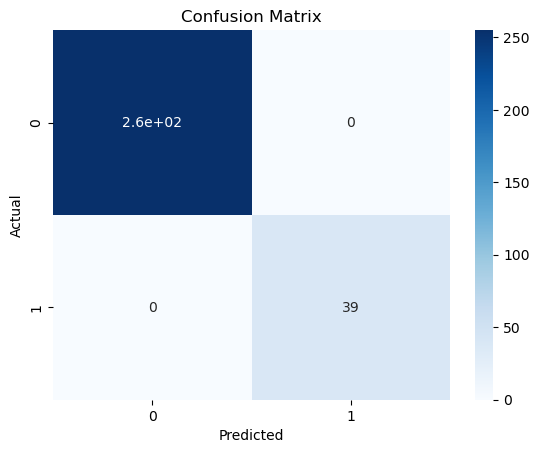

In [53]:
print("Random Forest Accuracy:", accuracy_score(Y_test, Y_pred))
print("\nClassification Report:")
print(classification_report(Y_test, Y_pred))

# Confusion Matrix
cm = confusion_matrix(Y_test, Y_pred)

sns.heatmap(cm, annot=True, cmap='Blues')
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

In [59]:
# Probability of attrition
risk_probs = model.predict_proba(X)[:, 1]  

# Convert to %
data2['Attrition_Risk_Score'] = risk_probs * 100  

# Risk categories
def risk_category(score):
    if score < 20: 
        return 'Low Risk'
    elif score < 50: 
        return 'Medium Risk'
    else: 
        return 'High Risk'

data2['Risk_Level'] = data2['Attrition_Risk_Score'].apply(risk_category)

print("Risk Distribution:")
print(data2['Risk_Level'].value_counts())
print("\nHigh Risk employees:", len(data2[data2['Risk_Level']=='High Risk']))

Risk Distribution:
Risk_Level
Low Risk       1232
High Risk       237
Medium Risk       1
Name: count, dtype: int64

High Risk employees: 237


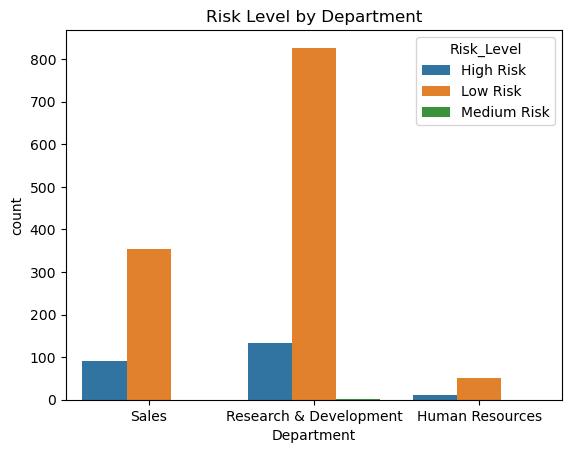

In [60]:
# Risk by department
sns.countplot(x='Department', hue='Risk_Level', data=data2)
plt.title('Risk Level by Department') 
plt.show()

Text(0.5, 1.0, 'Monthly Income by Risk Level')

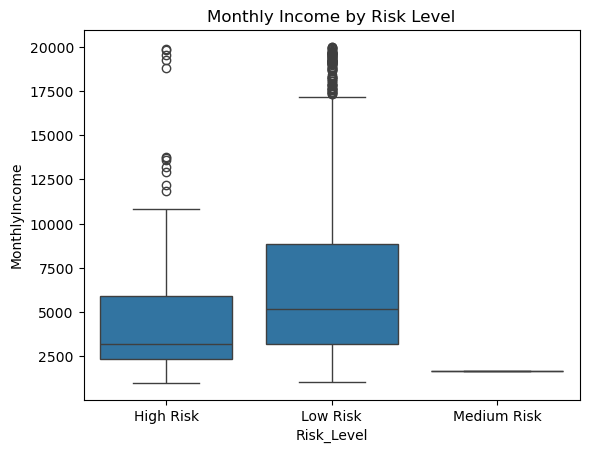

In [62]:
# Monthly income and risk factor
sns.boxplot(x='Risk_Level', y='MonthlyIncome', data=data2)
plt.title('Monthly Income by Risk Level')

In [65]:
# Recomondation System
def give_recommendation(row):
    if row['OverTime'] == 'Yes':
        return 'Reduce overtime workload'
    
    elif row['JobSatisfaction'] <= 2:
        return 'Improve job satisfaction'
    
    elif row['YearsAtCompany'] < 3:
        return 'Provide mentor support'
    
    elif row['MonthlyIncome'] < data2['MonthlyIncome'].median():
        return 'Review salary'
    
    else:
        return 'Regular check-in'
data2['HR_Recommendations'] = data2.apply(give_recommendation, axis=1)

In [ ]:
# Final executive report
final_report = data2[[
    'Age', 'Department', 'JobRole', 'MonthlyIncome', 'OverTime', 
    'JobSatisfaction', 'YearsAtCompany', 'Attrition_Risk_Score', 
    'Risk_Level', 'HR_Recommendations'
]].sort_values('Attrition_Risk_Score', ascending = False)

final_report.to_csv('HR_Attrition_Risk_Report.csv', index = False)
print("File Created- ''HR_Attrition_Risk_Report.csv''")

# Summary stats
print("\n=== EXECUTIVE SUMMARY ===")
print("High Risk Employees: " ,len(data2[data2['Risk_Level']=='High Risk']))
print("Average Risk Score: ",data2['Attrition_Risk_Score'].mean())